# ABS Data Pre-Processing

Currently only uses G02

- interest rates 

## Libraries

In [23]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data 

In [24]:
#Census G02 dataset which records median age, median income and other relevant medians.
abs_sa2_g02 = pd.read_csv('data/2021Census_G02_AUST_SA2.csv')
abs_sa2_g02.head()

,SA2_CODE_2021,Median_age_persons,Median_mortgage_repay_monthly,Median_tot_prsnl_inc_weekly,Median_rent_weekly,Median_tot_fam_inc_weekly,Average_num_psns_per_bedroom,Median_tot_hhd_inc_weekly,Average_household_size
0,101021007,51,1732,760,330,1886,0.8,1429,2.2
1,101021008,38,1950,975,350,2334,0.8,1989,2.6
2,101021009,37,1700,996,330,2233,0.9,1703,2.1
3,101021010,36,1700,1104,310,2412,0.9,1796,2.1
4,101021012,37,2300,1357,430,3332,0.8,3014,2.9


For BNPL, users tend to: 
- be younger 
- have less disposable income
- (maybe) lower household size?

## Profile

In [25]:
print(f"Shape of the dataset: {abs_sa2_g02.shape}")
print(f"unique SA2 codes: {abs_sa2_g02['SA2_CODE_2021'].nunique()}")
print(f"duplicate SA2 codes: {abs_sa2_g02['SA2_CODE_2021'].duplicated().sum()}")
print(abs_sa2_g02.info())

Shape of the dataset: (2472, 9)
unique SA2 codes: 2472
duplicate SA2 codes: 0
<class 'pandas.DataFrame'>
RangeIndex: 2472 entries, 0 to 2471
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   SA2_CODE_2021                  2472 non-null   int64  
 1   Median_age_persons             2472 non-null   int64  
 2   Median_mortgage_repay_monthly  2472 non-null   int64  
 3   Median_tot_prsnl_inc_weekly    2472 non-null   int64  
 4   Median_rent_weekly             2472 non-null   int64  
 5   Median_tot_fam_inc_weekly      2472 non-null   int64  
 6   Average_num_psns_per_bedroom   2472 non-null   float64
 7   Median_tot_hhd_inc_weekly      2472 non-null   int64  
 8   Average_household_size         2472 non-null   float64
dtypes: float64(2), int64(7)
memory usage: 173.9 KB
None


No null or duplicate SA2 codes ✅
missing values seem to be recorded as 0 from visual inspection/sanity check (median rent cannot be 0 unless it is not recorded or it is not a residential zone)

In [26]:
#print number of 0 per column
zero_counts = (abs_sa2_g02 == 0).sum()
print(f"Number of 0 values per column:\n{zero_counts}")

#print number of sa2 codes with 0 in any column per state (digit 1 of SA2 code indicates state)
zero_sa2_codes_per_state = zero_sa2_codes.astype(str).str[0].value_counts()
print(f"Number of SA2 codes with 0 values in any column per state:\n{zero_sa2_codes_per_state}")

#replace 0 with NaN values for all columns
abs_sa2_g02_no_zeros = abs_sa2_g02.replace(0, np.nan)


Number of 0 values per column:
SA2_CODE_2021                      0
Median_age_persons                38
Median_mortgage_repay_monthly    111
Median_tot_prsnl_inc_weekly       42
Median_rent_weekly                80
Median_tot_fam_inc_weekly         69
Average_num_psns_per_bedroom      55
Median_tot_hhd_inc_weekly         58
Average_household_size            55
dtype: int64
Number of SA2 codes with 0 values in any column per state:
SA2_CODE_2021
8    24
5    21
3    19
1    17
7    14
4    11
2     9
6     5
9     2
Name: count, dtype: int64


ACT (8), WA (5), QLD (3) have highest nulls, but low proportion overall. 
*My vote is to exclude*

## Outlier Analysis

⛳️ 2000 + rows, so use the sqrt(logN) - 0.5 ??? for now I used 3 and we can adjust 

In [27]:
# Helper functions to identify and visualise outliers using the IQR method (threshold = 3)

def iqr_outliers(df, column, threshold=3):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

def plot_distribution_with_outliers(df, column):
    outliers = iqr_outliers(df, column)
    plt.figure(figsize=(12, 6))
    sns.histplot(df[column], bins=30, kde=True, color='blue', label='Data')
    sns.histplot(outliers[column], bins=30, kde=True, color='red', label='Outliers')
    plt.title(f'Distribution of {column} with Outliers Highlighted')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()


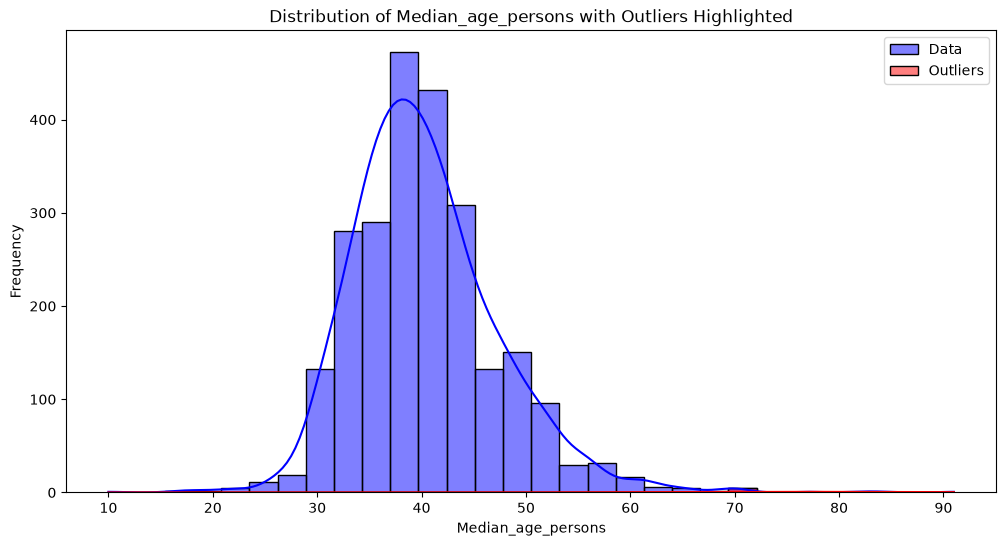

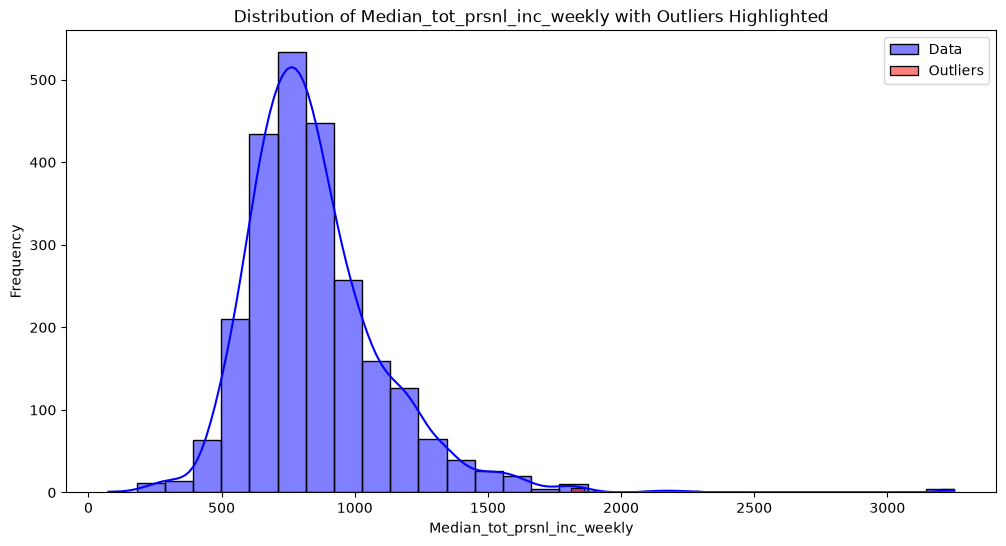

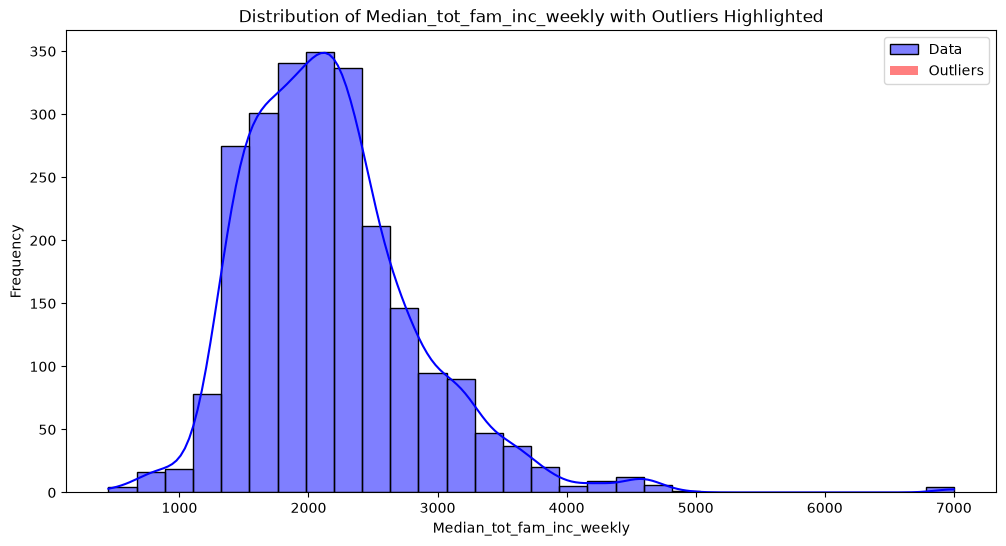

In [30]:
# use for loop to iterate through all relevant columns and plot distribution with outliers highlighted
relevant_cols = ['Median_age_persons', 'Median_tot_prsnl_inc_weekly', 'Median_tot_fam_inc_weekly']

for column in relevant_cols:
    plot_distribution_with_outliers(abs_sa2_g02_no_zeros, column)   

relevant columns are mostly normal with slight right skew. 

Correlation between Median Age and Median Personal Income: -0.19859872300275655
Correlation between Median Age and Median Family Income: -0.18882984434311925


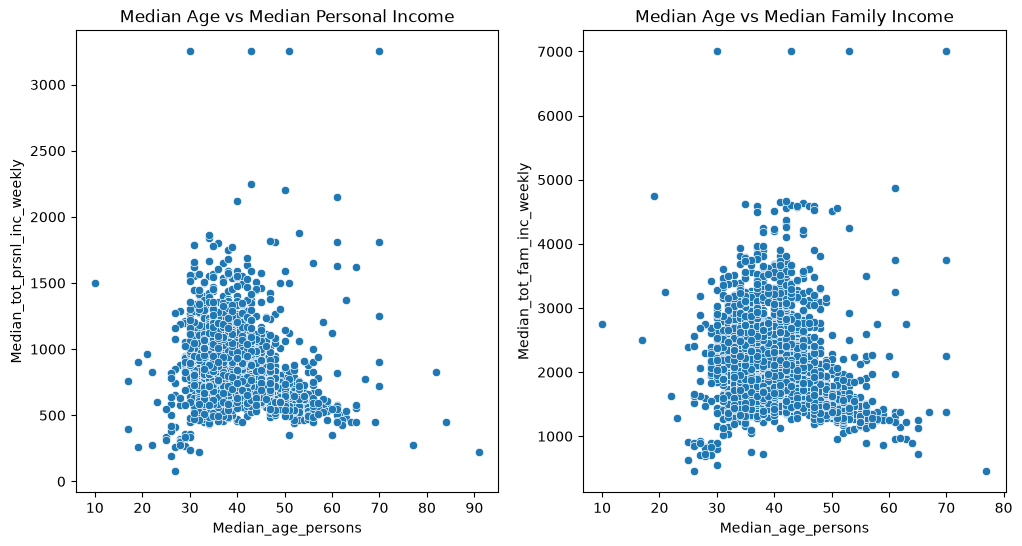

In [32]:
#Correlation between age and household income, and age and family income. Use scatter plots to visualise the relationships.
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(data=abs_sa2_g02_no_zeros, x='Median_age_persons', y='Median_tot_prsnl_inc_weekly')
plt.title('Median Age vs Median Personal Income')
plt.subplot(1, 2, 2)
sns.scatterplot(data=abs_sa2_g02_no_zeros, x='Median_age_persons', y='Median_tot_fam_inc_weekly')
plt.title('Median Age vs Median Family Income')     

#print correlation coefficients
corr_personal_income = abs_sa2_g02_no_zeros['Median_age_persons'].corr(abs_sa2_g02_no_zeros['Median_tot_prsnl_inc_weekly'])
corr_family_income = abs_sa2_g02_no_zeros['Median_age_persons'].corr(abs_sa2_g02_no_zeros['Median_tot_fam_inc_weekly'])
print(f"Correlation between Median Age and Median Personal Income: {corr_personal_income}")
print(f"Correlation between Median Age and Median Family Income: {corr_family_income}")

straight line at top --> max for ABS data?? cap/censor? will remove 


## Geospatial Plot 

['SA2_CODE21', 'SA2_NAME21', 'CHG_FLAG21', 'CHG_LBL21', 'SA3_CODE21', 'SA3_NAME21', 'SA4_CODE21', 'SA4_NAME21', 'GCC_CODE21', 'GCC_NAME21', 'STE_CODE21', 'STE_NAME21', 'AUS_CODE21', 'AUS_NAME21', 'AREASQKM21', 'LOCI_URI21', 'geometry']
['SA2_CODE_2021', 'Median_age_persons', 'Median_mortgage_repay_monthly', 'Median_tot_prsnl_inc_weekly', 'Median_rent_weekly', 'Median_tot_fam_inc_weekly', 'Average_num_psns_per_bedroom', 'Median_tot_hhd_inc_weekly', 'Average_household_size']


<Figure size 1000x1000 with 0 Axes>

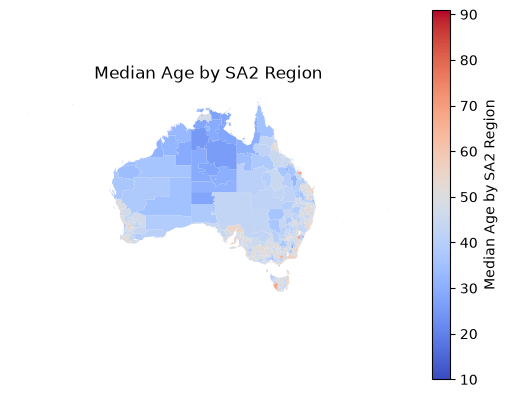

In [45]:
import geopandas as gpd

sa2_shapefile = gpd.read_file('data/SA2_2021_AUST_GDA2020.shp')
sa2_shapefile['SA2_CODE21'] = sa2_shapefile['SA2_CODE21'].astype(str)
abs_sa2_g02_no_zeros['SA2_CODE_2021'] = abs_sa2_g02_no_zeros['SA2_CODE_2021'].astype(str)
print(sa2_shapefile.columns.tolist())
print(abs_sa2_g02_no_zeros.columns.tolist())

#plot a graph of the SA2 regions with median age as a color gradient
merged = sa2_shapefile.merge(abs_sa2_g02_no_zeros, left_on='SA2_CODE21', right_on='SA2_CODE_2021')
plt.figure(figsize=(10, 10))
merged.plot(column='Median_age_persons', cmap='coolwarm', legend=True, legend_kwds={'label': "Median Age by SA2 Region"})
plt.title('Median Age by SA2 Region')
plt.axis('off') 
plt.show()

# Re-Do for other tables 

- sex 

- average income by age by sex? I assume we have this customer data. 